# Ablation study — progress monitor

Scans `out/<mode>/<label>/<run_id>/` (labels `Book<B>_Prop<NN>_<model>`) and shows, live, across **all books** (Book 1/2/3). Props are labelled **`B.NN`** — book.prop, e.g. `2.11` — so same-numbered props in different books never collide.

1. **Runs done per prop** — how many *finished* runs each prop has vs the target (e.g. `1.3` = 3/3 **done**, `2.8` = 2/3 still going). Bars stack strictly by outcome: **ok** (green, SUCCESS) · **timeout** (purple, the 12 h global-wall hit — counts as finished) · **fail** (red, FAIL/GAVEUP) · **running** (grey). No done/not-done tint.
2. **Wall time for every run** — one bar per run, in hours.
   - **Finished** runs (SUCCESS/GAVEUP/FAIL) use `wall_sec` from `result.txt`.
   - **TIMEOUT** runs are pinned to the **12 h cap** (`WALL_LIMIT_HR`): the watchdog kills the run at exactly `t0 + 12 h`, so the cap is the true wall.
   - **RUNNING** runs use `now − transcript_start` (hatched `//`) so the bar keeps growing until the run finishes.
3. **Cost for every run** — one bar per run, in USD, from `result.txt`'s `cost_usd`. RUNNING runs have no `result.txt` yet, so their cost is unknown (no bar).
4. **Total cost per method** — the summed `cost_usd` across every run of each method/mode.

Re-run all cells to refresh. **Kernel:** a Python with pandas + matplotlib — e.g. `~/.venvs/euclid/bin/python`.

In [1]:
# ---- config ----------------------------------------------------------------
MODEL         = "opus"   # selects run folders whose label ends _<MODEL>
TARGET_RUNS   = 3        # a prop is "done" once it has this many FINISHED runs
WALL_LIMIT_HR = 12.0     # driver's global watchdog kills a run at exactly this many hours
OUT_BASE      = "/home/user/code/autoform/Pistis/reproducable_experiments/ablation_study/out"

import os, glob, json, re
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TERMINAL = run is no longer running (has a real final outcome). TIMEOUT = 12h wall hit.
TERMINAL    = {"SUCCESS", "GAVEUP", "FAIL", "TIMEOUT"}
RESULT_COL  = {"SUCCESS": "#2ca02c", "GAVEUP": "#ff7f0e", "FAIL": "#d62728",
               "TIMEOUT": "#9467bd", "RUNNING": "#9e9e9e"}
MODE_COL    = {"mymethod": "#1f77b4", "ablated": "#ff7f0e"}
NOW         = datetime.now(timezone.utc)
print("reference 'now' =", NOW.isoformat())

reference 'now' = 2026-07-28T18:47:49.803833+00:00


In [2]:
# ---- helpers ---------------------------------------------------------------
def parse_result(path):
    """result.txt -> dict of its 'key: value' lines."""
    d = {}
    for line in open(path):
        k, sep, v = line.partition(":")
        if sep:
            d[k.strip()] = v.strip()
    return d

def transcript_span(tpath):
    """(start, end) UTC datetimes from a transcript.jsonl, or (None, None)."""
    start = end = None
    try:
        with open(tpath) as f:
            for line in f:
                if '"timestamp"' not in line:
                    continue
                try:
                    ts = json.loads(line).get("timestamp")
                except Exception:
                    continue
                if not ts:
                    continue
                dt = datetime.fromisoformat(ts.replace("Z", "+00:00"))
                if start is None or dt < start:
                    start = dt
                if end is None or dt > end:
                    end = dt
    except FileNotFoundError:
        pass
    return start, end

In [3]:
# ---- discover every run (finished OR still running) ------------------------
rows = []
for run_dir in glob.glob(os.path.join(OUT_BASE, "*", f"*_{MODEL}", "*")):
    if not os.path.isdir(run_dir):
        continue
    parts  = run_dir.rstrip(os.sep).split(os.sep)
    mode   = parts[-3]            # e.g. ablated / mymethod
    label  = parts[-2]            # e.g. Book2_Prop11_opus
    run_id = parts[-1]            # e.g. 20260719-193910-fab15842

    rpath = os.path.join(run_dir, "result.txt")
    d      = parse_result(rpath) if os.path.exists(rpath) else {}
    result = d.get("result", "RUNNING").upper()   # no result.txt yet => RUNNING
    finished = result in TERMINAL                  # TERMINAL includes TIMEOUT

    # The local transcript.jsonl is only copied into the run dir when the run
    # FINISHES; while a run is RUNNING its transcript lives at the live session
    # path recorded in result.txt's 'transcript:' field. Read whichever exists.
    tpath = os.path.join(run_dir, "transcript.jsonl")
    if not os.path.exists(tpath):
        tpath = d.get("transcript", tpath)
    start, end = transcript_span(tpath)

    # wall time, by outcome:
    #   TIMEOUT  -> pin to the 12h cap. The global watchdog kills the run at
    #              exactly t0 + WALL_LIMIT, so 12h IS the true wall. result.txt's
    #              wall_sec is a stale per-round value and the transcript span
    #              undercounts (the final hung build emits no records) -> use neither.
    #   finished -> result.txt's final wall_sec.
    #   running  -> now - transcript_start (result.txt wall_sec is stale).
    wall_final = pd.to_numeric(d.get("wall_sec"), errors="coerce")
    if result == "TIMEOUT":
        wall_sec, wall_src = WALL_LIMIT_HR * 3600.0, "12h cap"
    elif finished and not np.isnan(wall_final):
        wall_sec, wall_src = float(wall_final), "result.txt"
    elif start is not None:
        wall_sec, wall_src = (NOW - start).total_seconds(), "now - transcript_start"
    else:
        wall_sec, wall_src = np.nan, "unknown"

    # cost is only recorded in result.txt (finished runs). RUNNING => NaN (unknown).
    cost_usd = pd.to_numeric(d.get("cost_usd"), errors="coerce")

    # label is Book<B>_Prop<NN>_<model>: pull the book AND prop number.
    mb = re.search(r"Book0*(\d+)", label)
    mp = re.search(r"Prop0*(\d+)", label)
    booknum = int(mb.group(1)) if mb else -1
    propnum = int(mp.group(1)) if mp else -1

    rows.append(dict(
        mode=mode, label=label, run_id=run_id,
        booknum=booknum, propnum=propnum,
        prop_label=f"{booknum}.{propnum}",     # B.NN, e.g. 2.11
        result=result, finished=finished,
        timeout=(result == "TIMEOUT"),
        wall_sec=wall_sec, wall_min=wall_sec / 60.0, wall_hr=wall_sec / 3600.0, wall_src=wall_src,
        cost_usd=float(cost_usd) if not np.isnan(cost_usd) else np.nan,
        start=start, end=end,
    ))

df = pd.DataFrame(rows).sort_values(["mode", "booknum", "propnum", "run_id"]).reset_index(drop=True)
print(f"{len(df)} runs across modes={sorted(df['mode'].unique()) if not df.empty else []}, "
      f"books={sorted(df['booknum'].unique()) if not df.empty else []}")
if not df.empty:
    print("outcomes:", df["result"].value_counts().to_dict())
df[["mode", "prop_label", "run_id", "result", "finished", "wall_hr", "cost_usd", "wall_src"]] if not df.empty else df

90 runs across modes=['ablated', 'mymethod'], books=[np.int64(1), np.int64(2), np.int64(3)]
outcomes: {'SUCCESS': 61, 'TIMEOUT': 29}


,mode,prop_label,run_id,result,finished,wall_hr,cost_usd,wall_src
0,ablated,1.3,20260719-193910-fab15842,SUCCESS,True,0.069541,1.59686,result.txt
1,ablated,1.3,20260719-194334-95d75e25,SUCCESS,True,0.058090,1.37590,result.txt
2,ablated,1.3,20260719-194714-c7332038,SUCCESS,True,0.057399,1.32310,result.txt
3,ablated,1.6,20260719-193910-deed27fd,SUCCESS,True,0.211798,4.71706,result.txt
4,ablated,1.6,20260719-195213-a92accb8,SUCCESS,True,0.447239,4.91380,result.txt
...,...,...,...,...,...,...,...,...
85,mymethod,3.25,20260722-163637-8fc9b0ac,SUCCESS,True,2.151164,25.54590,result.txt
86,mymethod,3.25,20260722-190620-e45f8b26,SUCCESS,True,2.443736,34.17720,result.txt
87,mymethod,3.36,20260722-114914-f7c81e6c,SUCCESS,True,1.906908,27.23870,result.txt
88,mymethod,3.36,20260722-152107-8c876bd1,SUCCESS,True,3.507694,39.80290,result.txt


In [4]:
# ---- per-prop progress: finished vs target ---------------------------------
# Grouped by (book, prop) so Book1/Book2/Book3 props with the same number don't
# collide. Outcome buckets: ok (SUCCESS) · fail (FAIL/GAVEUP) · timeout · running.
def summarize(df):
    recs = []
    for (mode, booknum, propnum, label), x in df.groupby(["mode", "booknum", "propnum", "prop_label"]):
        n_fin = int(x["finished"].sum())
        n_to  = int(x["timeout"].sum())
        n_ok  = int((x["result"] == "SUCCESS").sum())
        n_fl  = int(x["result"].isin(["FAIL", "GAVEUP"]).sum())
        recs.append(dict(
            mode=mode, booknum=booknum, propnum=propnum, prop_label=label,
            n_runs=len(x), n_finished=n_fin,
            n_success=n_ok, n_fail=n_fl, n_timeout=n_to, n_running=len(x) - n_fin,
            cost_usd=float(x["cost_usd"].sum(skipna=True)),
            done=n_fin >= TARGET_RUNS,
            progress=f"{n_fin}/{TARGET_RUNS}",
        ))
    return pd.DataFrame(recs).sort_values(["mode", "booknum", "propnum"]).reset_index(drop=True)

summ = summarize(df) if not df.empty else pd.DataFrame()
summ

,mode,booknum,propnum,prop_label,n_runs,n_finished,n_success,n_fail,n_timeout,n_running,cost_usd,done,progress
0,ablated,1,3,1.3,3,3,3,0,0,0,4.29586,True,3/3
1,ablated,1,6,1.6,3,3,3,0,0,0,12.94107,True,3/3
2,ablated,1,12,1.12,3,3,3,0,0,0,12.34108,True,3/3
3,ablated,1,18,1.18,3,3,3,0,0,0,8.90558,True,3/3
4,ablated,1,20,1.20,3,3,0,0,3,0,15.85806,True,3/3
5,ablated,1,27,1.27,3,3,1,0,2,0,16.16615,True,3/3
6,ablated,1,30,1.30,3,3,0,0,3,0,14.78668,True,3/3
7,ablated,1,36,1.36,3,3,0,0,3,0,20.58962,True,3/3
8,ablated,1,45,1.45,3,3,0,0,3,0,25.78990,True,3/3
9,ablated,2,3,2.3,3,3,0,0,3,0,73.00830,True,3/3


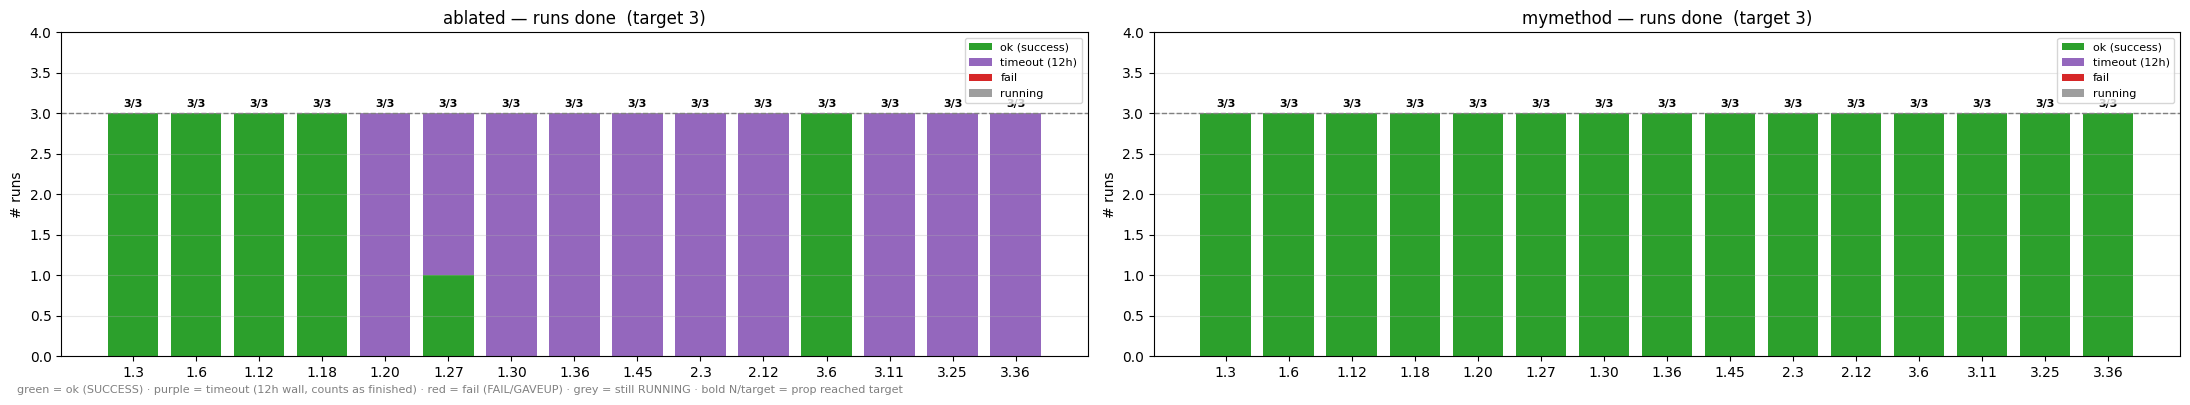

In [5]:
# ---- PLOT 1: runs done per prop (one subplot per mode) ---------------------
# Bars stack bottom -> top, coloured strictly by OUTCOME (no done/not-done tint):
#   ok (green, SUCCESS) + timeout (purple, 12h wall) + fail (red, FAIL/GAVEUP)
#   + running (grey).  A bold N/target label marks a prop that has hit the target.
if not summ.empty:
    modes = sorted(summ["mode"].unique())
    fig, axes = plt.subplots(1, len(modes),
                             figsize=(max(5, 0.6 * summ["prop_label"].nunique() + 2) * len(modes), 4),
                             squeeze=False)
    for ax, mode in zip(axes[0], modes):
        s = summ[summ["mode"] == mode].sort_values(["booknum", "propnum"])
        x = np.arange(len(s))
        bot = np.zeros(len(s))
        for col, key, lab in [("n_success", "SUCCESS", "ok (success)"),
                              ("n_timeout", "TIMEOUT", "timeout (12h)"),
                              ("n_fail",    "FAIL",    "fail"),
                              ("n_running", "RUNNING", "running")]:
            vals = s[col].to_numpy(float)
            ax.bar(x, vals, bottom=bot, color=RESULT_COL[key], label=lab)
            bot = bot + vals
        ax.axhline(TARGET_RUNS, ls="--", color="gray", lw=1)
        for xi, (_, r) in zip(x, s.iterrows()):
            ax.text(xi, r["n_runs"] + 0.05, r["progress"], ha="center", va="bottom",
                    fontsize=8, fontweight="bold" if r["done"] else "normal")
        ax.set_xticks(x); ax.set_xticklabels(s["prop_label"], rotation=0)
        ax.set_ylabel("# runs"); ax.set_title(f"{mode} — runs done  (target {TARGET_RUNS})")
        ax.set_ylim(0, max(TARGET_RUNS, summ["n_runs"].max()) + 1)
        ax.grid(axis="y", alpha=0.3); ax.legend(loc="upper right", fontsize=8)
    fig.text(0.01, 0.005,
             "green = ok (SUCCESS) · purple = timeout (12h wall, counts as finished) · "
             "red = fail (FAIL/GAVEUP) · grey = still RUNNING · "
             "bold N/target = prop reached target",
             fontsize=8, color="gray")
    plt.tight_layout(); plt.show()
else:
    print("no runs found")

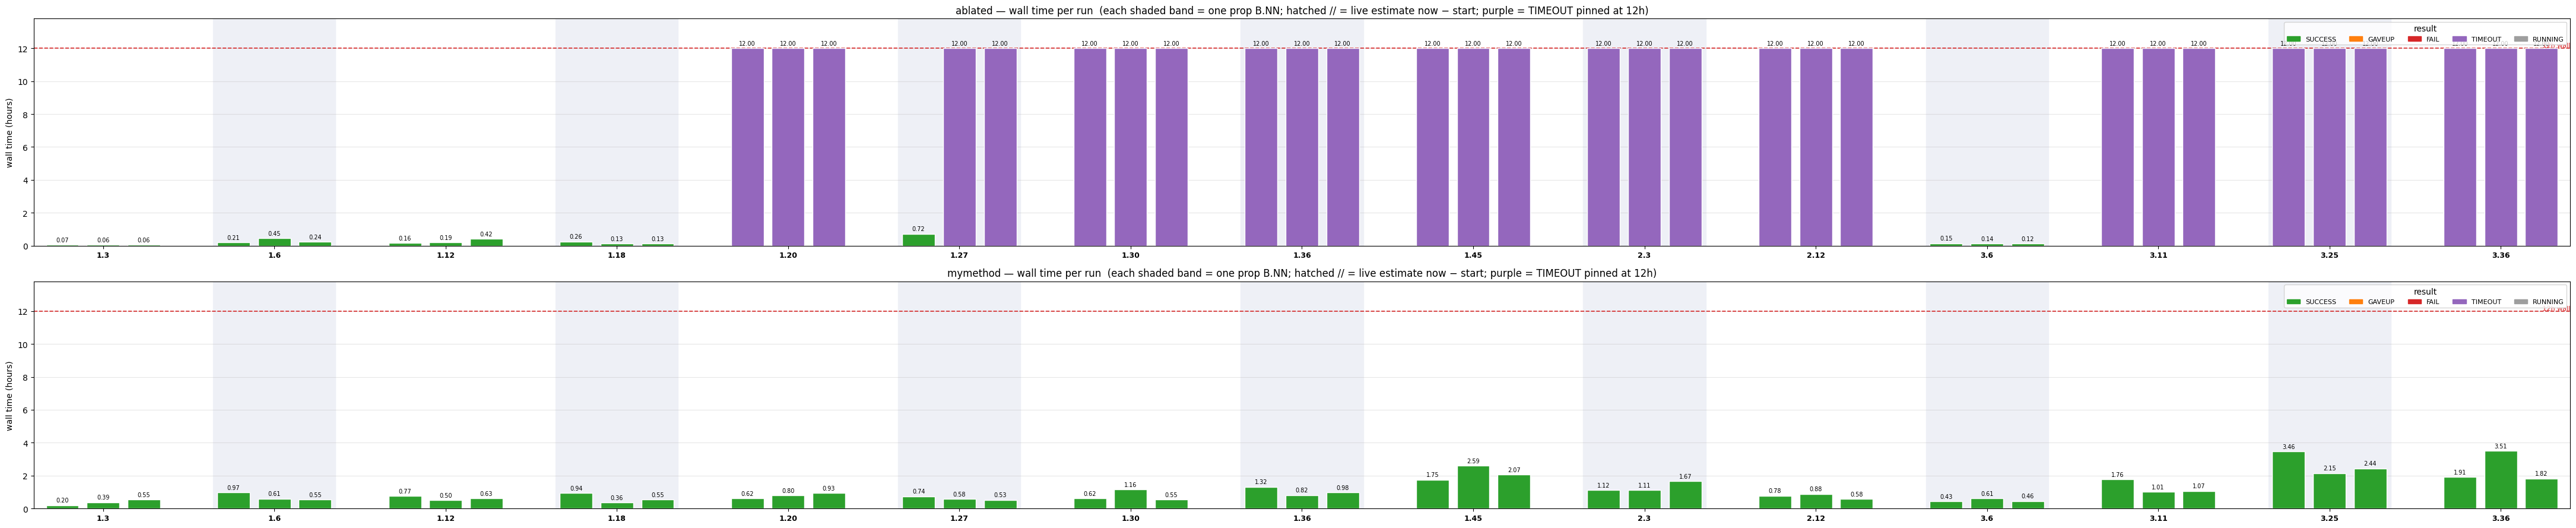

In [6]:
# ---- PLOT 2 (final): wall time for EVERY run, grouped by prop --------------
# One bar per run, in HOURS. Bar height by outcome:
#   SUCCESS/GAVEUP/FAIL -> result.txt wall_sec (solid)
#   TIMEOUT (purple)    -> pinned to the 12h cap (solid); the watchdog killed it
#                          there, so 12h is the true wall (see the discover cell)
#   RUNNING (grey)      -> now - transcript_start (hatched //, live estimate, grows)
# A dashed red line marks the 12h global wall. Each prop's runs sit in their OWN
# shaded band with a gap + a bold B.NN tick (book.prop), so it is always
# unambiguous which bars belong to which proposition.
if not df.empty:
    GAP = 1.2   # empty x-space between one prop's group of bars and the next
    modes = sorted(df["mode"].unique())
    fig, axes = plt.subplots(len(modes), 1,
                             figsize=(max(9, 0.45 * len(df) + 3), 4.5 * len(modes)),
                             squeeze=False)
    for ax, mode in zip(axes[:, 0], modes):
        sub = df[df["mode"] == mode].sort_values(["booknum", "propnum", "run_id"]).reset_index(drop=True)

        # lay out each prop's bars contiguously, with GAP between groups
        pos, group_spans, cursor = [], [], 0.0
        for (bn, pn), g in sub.groupby(["booknum", "propnum"]):
            xs = [cursor + i for i in range(len(g))]
            pos.extend(xs)
            group_spans.append(((bn, pn), len(g), xs[0], xs[-1]))
            cursor = xs[-1] + 1 + GAP
        x = np.array(pos)
        wmax = float(np.nanmax(sub["wall_hr"].to_numpy())) if len(sub) else 1.0
        ymax = max(wmax, WALL_LIMIT_HR)          # always keep the 12h line in view

        # alternating shaded band behind each prop's group; bold B.NN on the axis
        centers, tlabels = [], []
        for k, ((bn, pn), n, x0, x1) in enumerate(group_spans):
            ax.axvspan(x0 - 0.5, x1 + 0.5, color="#eef0f6" if k % 2 else "#ffffff", zorder=0)
            centers.append((x0 + x1) / 2.0); tlabels.append(f"{bn}.{pn}")

        # the 12h global wall (TIMEOUT bars sit exactly on it)
        ax.axhline(WALL_LIMIT_HR, ls="--", color="#d62728", lw=1.2, zorder=2)
        ax.text(cursor - GAP - 0.3, WALL_LIMIT_HR, f" {WALL_LIMIT_HR:g}h wall",
                ha="right", va="bottom", fontsize=8, color="#d62728", zorder=5)

        colors = [RESULT_COL.get(r, "#333333") for r in sub["result"]]
        ax.bar(x, sub["wall_hr"], width=0.8, color=colors, zorder=3,
               hatch=["//" if not f else "" for f in sub["finished"]], edgecolor="white")
        for xi, w in zip(x, sub["wall_hr"]):
            if w == w:
                ax.text(xi, w + ymax * 0.01, f"{w:.2f}", ha="center", va="bottom",
                        fontsize=7, zorder=4)

        ax.set_xticks(centers)
        ax.set_xticklabels(tlabels, fontsize=9, fontweight="bold")
        ax.set_xlim(-0.7, cursor - GAP - 0.3)
        ax.set_ylim(0, ymax * 1.15)
        ax.set_ylabel("wall time (hours)")
        ax.set_title(f"{mode} — wall time per run  (each shaded band = one prop B.NN; "
                     f"hatched // = live estimate now − start; purple = TIMEOUT pinned at 12h)")
        ax.grid(axis="y", alpha=0.3, zorder=1)
        handles = [plt.Rectangle((0, 0), 1, 1, color=RESULT_COL[k]) for k in RESULT_COL]
        ax.legend(handles, list(RESULT_COL), title="result", fontsize=8, ncol=5, loc="upper right")
    plt.tight_layout(); plt.show()
else:
    print("no runs found")

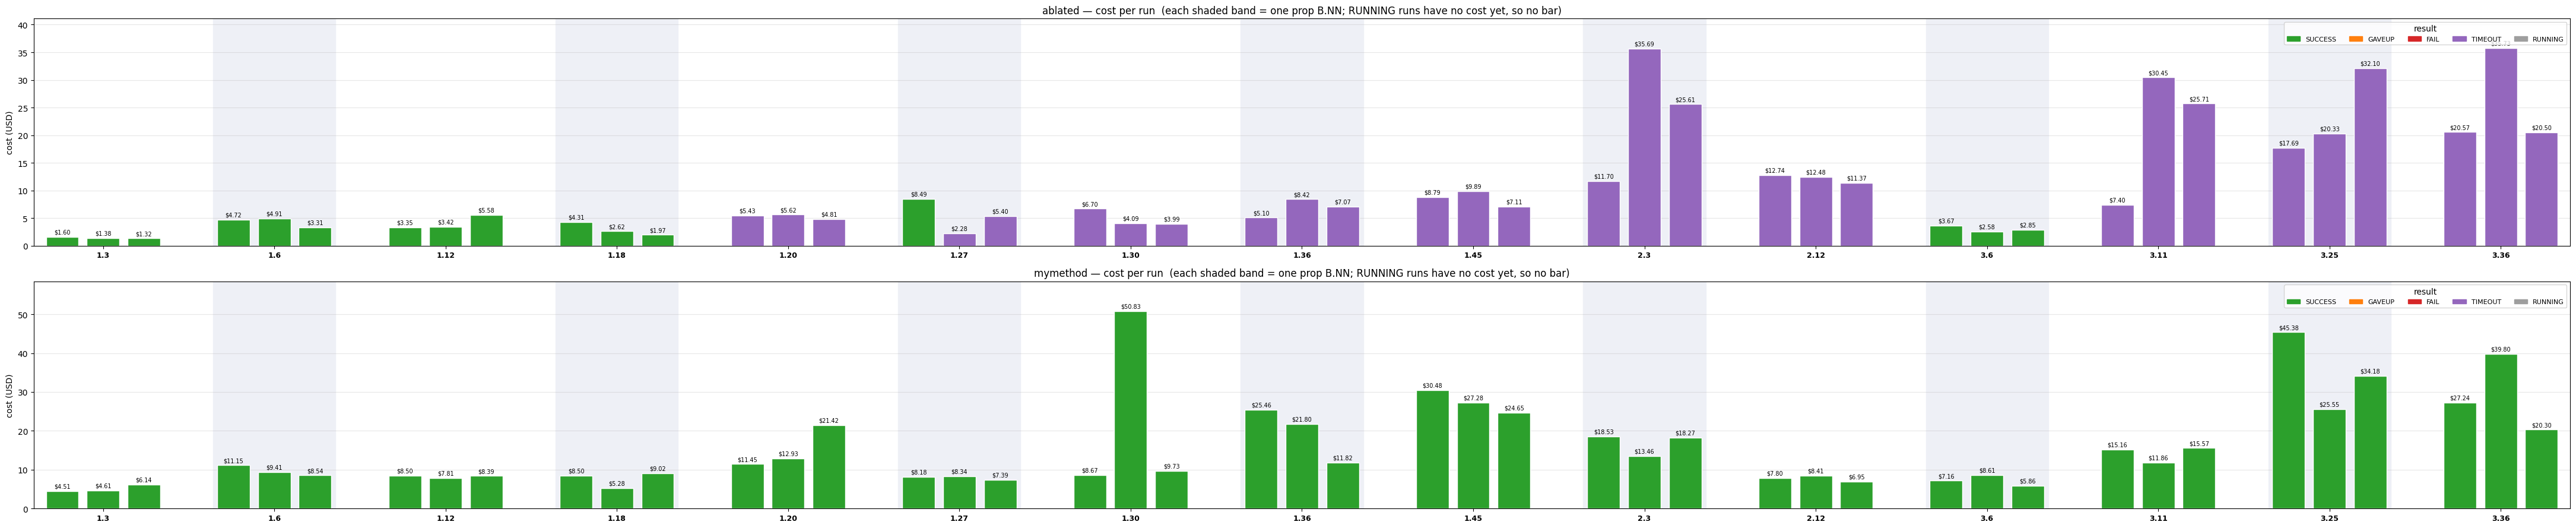

In [7]:
# ---- PLOT 3 (final): USD cost for EVERY run, grouped by prop ---------------
# One bar per run, in DOLLARS, from result.txt's cost_usd. Layout mirrors PLOT 2:
# each prop's runs sit in their own shaded band with a bold B.NN tick.
#   SUCCESS/GAVEUP/FAIL/TIMEOUT -> cost_usd from result.txt (solid, coloured by outcome)
#   RUNNING                     -> no result.txt yet, so cost is UNKNOWN (NaN -> no bar)
if not df.empty:
    GAP = 1.2   # empty x-space between one prop's group of bars and the next
    modes = sorted(df["mode"].unique())
    fig, axes = plt.subplots(len(modes), 1,
                             figsize=(max(9, 0.45 * len(df) + 3), 4.5 * len(modes)),
                             squeeze=False)
    for ax, mode in zip(axes[:, 0], modes):
        sub = df[df["mode"] == mode].sort_values(["booknum", "propnum", "run_id"]).reset_index(drop=True)

        # lay out each prop's bars contiguously, with GAP between groups
        pos, group_spans, cursor = [], [], 0.0
        for (bn, pn), g in sub.groupby(["booknum", "propnum"]):
            xs = [cursor + i for i in range(len(g))]
            pos.extend(xs)
            group_spans.append(((bn, pn), len(g), xs[0], xs[-1]))
            cursor = xs[-1] + 1 + GAP
        x = np.array(pos)
        cmax = float(np.nanmax(sub["cost_usd"].to_numpy())) if sub["cost_usd"].notna().any() else 1.0
        ymax = cmax if cmax > 0 else 1.0

        # alternating shaded band behind each prop's group; bold B.NN on the axis
        centers, tlabels = [], []
        for k, ((bn, pn), n, x0, x1) in enumerate(group_spans):
            ax.axvspan(x0 - 0.5, x1 + 0.5, color="#eef0f6" if k % 2 else "#ffffff", zorder=0)
            centers.append((x0 + x1) / 2.0); tlabels.append(f"{bn}.{pn}")

        colors = [RESULT_COL.get(r, "#333333") for r in sub["result"]]
        ax.bar(x, sub["cost_usd"], width=0.8, color=colors, zorder=3,
               hatch=["//" if not f else "" for f in sub["finished"]], edgecolor="white")
        for xi, c in zip(x, sub["cost_usd"]):
            if c == c:   # skip NaN (RUNNING runs, no cost yet)
                ax.text(xi, c + ymax * 0.01, f"${c:.2f}", ha="center", va="bottom",
                        fontsize=7, zorder=4)

        ax.set_xticks(centers)
        ax.set_xticklabels(tlabels, fontsize=9, fontweight="bold")
        ax.set_xlim(-0.7, cursor - GAP - 0.3)
        ax.set_ylim(0, ymax * 1.15)
        ax.set_ylabel("cost (USD)")
        ax.set_title(f"{mode} — cost per run  (each shaded band = one prop B.NN; "
                     f"RUNNING runs have no cost yet, so no bar)")
        ax.grid(axis="y", alpha=0.3, zorder=1)
        handles = [plt.Rectangle((0, 0), 1, 1, color=RESULT_COL[k]) for k in RESULT_COL]
        ax.legend(handles, list(RESULT_COL), title="result", fontsize=8, ncol=5, loc="upper right")
    plt.tight_layout(); plt.show()
else:
    print("no runs found")

In [8]:
# ---- total cost per method -------------------------------------------------
# Sum of cost_usd over every run of each method/mode (all books, all props).
# RUNNING runs have no cost recorded yet, so they contribute nothing.
if not df.empty:
    for mode, g in df.groupby("mode"):
        total  = g["cost_usd"].sum(skipna=True)
        n_cost = int(g["cost_usd"].notna().sum())
        print(f"{mode}: ${total:,.2f}  "
              f"({n_cost} run(s) with cost, {len(g) - n_cost} still running / no cost)")
    print("-" * 48)
    print(f"ALL METHODS: ${df['cost_usd'].sum(skipna=True):,.2f}")
else:
    print("no runs found")

ablated: $460.87  (45 run(s) with cost, 0 still running / no cost)
mymethod: $702.35  (45 run(s) with cost, 0 still running / no cost)
------------------------------------------------
ALL METHODS: $1,163.22
